<a href="https://colab.research.google.com/github/kelvin-yg98/Kelvin-Programming/blob/main/Building_a_Leakage_Safe_Preprocessing_Pipeline_in_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv(url, names=column_names, skipinitialspace=True, na_values="?")
df["income"] = (df["income"].str.strip(". ") == ">50K").astype(int)

# Keep only 6 distinct, high-impact features
selected_cols = [
    "capital-gain", "hours-per-week",  # Numerical (1 heavily skewed, 1 standard)
    "marital-status",                  # Low-cardinality categorical
    "occupation", "native-country",    # High-cardinality categorical (for Target Encoding)
    "income"                           # Target
]

df_clean = df[selected_cols].copy()

In [4]:
num_cols = ["capital-gain", "hours-per-week"]

In [5]:
cat_low_card = ["marital-status"]

In [6]:
cat_high_card = ["occupation", "native-country"]

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, TargetEncoder

# 1. Numerical Pipeline
# Impute missing values -> Yeo-Johnson Power Transform -> Standard Scale
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# 2. Low-Cardinality Categorical Pipeline
# Impute missing values -> One-Hot Encode
cat_low_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# 3. High-Cardinality Categorical Pipeline
# Impute missing values -> Target Encode
cat_high_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('target_enc', TargetEncoder(smooth='auto', cv=5))
])

# Combine into a unified ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat_low', cat_low_pipeline, cat_low_card),
        ('cat_high', cat_high_pipeline, cat_high_card)
    ],
    remainder='drop'
)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Feature / Target Split
X = df_clean[num_cols + cat_low_card + cat_high_card]
y = df_clean["income"]

# 2. Assemble Full Model Pipeline
# Preprocessor + Estimator packed as a single estimator object
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

# 3. Setup Leak-Free Cross-Validation Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Execute Cross-Validation
cv_results = cross_validate(
    full_pipeline,
    X,
    y,
    cv=cv,
    scoring=['accuracy', 'roc_auc'],
    return_train_score=True,
    n_jobs=-1
)

# 5. Display Performance
print("=== Leak-Free Pipeline Cross-Validation Performance ===")
print(f"Mean Train ROC-AUC : {cv_results['train_roc_auc'].mean():.4f} ± {cv_results['train_roc_auc'].std():.4f}")
print(f"Mean Test ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"Mean Test Accuracy : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

=== Leak-Free Pipeline Cross-Validation Performance ===
Mean Train ROC-AUC : 0.9049 ± 0.0009
Mean Test ROC-AUC  : 0.8982 ± 0.0034
Mean Test Accuracy : 0.8479 ± 0.0035


In [9]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import TargetEncoder

# Custom Global Target Encoder to demonstrate naive/improper usage
class NaiveGlobalTargetEncoder(BaseEstimator, TransformerMixin):
    """
    Simulates improper workflow: Target Encoding fits on the FULL dataset (X, y)
    BEFORE cross-validation splits take place.
    """
    def __init__(self, cat_cols):
        self.cat_cols = cat_cols
        self.encoder = TargetEncoder(smooth='auto', cv=5)

    def fit_transform_global(self, X, y):
        X_encoded = X.copy()
        # LEAK: Fitting on full dataset y before CV
        X_encoded[self.cat_cols] = self.encoder.fit_transform(X[self.cat_cols], y)
        return X_encoded

# Setup cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------
# APPROACH A: LEAKED PIPELINE (Improper Global Encoding)
# ---------------------------------------------------------
naive_encoder = NaiveGlobalTargetEncoder(cat_cols=cat_high_card)
# 1. Fit target encoder on ALL data (Leakage happens here!)
X_leaked = naive_encoder.fit_transform_global(X, y)

# 2. Run CV on pre-transformed data
leaked_results = cross_validate(
    Pipeline([
        ('num_low_prep', ColumnTransformer([
            ('num', num_pipeline, num_cols),
            ('cat_low', cat_low_pipeline, cat_low_card)
        ], remainder='passthrough')),
        ('classifier', HistGradientBoostingClassifier(random_state=42))
    ]),
    X_leaked, y, cv=cv, scoring=['accuracy', 'roc_auc'], return_train_score=True, n_jobs=-1
)

# ---------------------------------------------------------
# APPROACH B: LEAK-FREE PIPELINE (Proper Enclosed Encoding)
# ---------------------------------------------------------
# TargetEncoder is fit ONLY inside each training fold during CV
clean_results = cross_validate(
    full_pipeline, X, y, cv=cv, scoring=['accuracy', 'roc_auc'], return_train_score=True, n_jobs=-1
)

# ---------------------------------------------------------
# COMPARISON METRICS
# ---------------------------------------------------------
metrics_df = pd.DataFrame({
    'Approach': ['Leaked (Global Target Encoding)', 'Proper (Pipeline Enclosed)'],
    'Train ROC-AUC': [leaked_results['train_roc_auc'].mean(), clean_results['train_roc_auc'].mean()],
    'Test ROC-AUC': [leaked_results['test_roc_auc'].mean(), clean_results['test_roc_auc'].mean()],
    'Generalization Gap (Train - Test)': [
        leaked_results['train_roc_auc'].mean() - leaked_results['test_roc_auc'].mean(),
        clean_results['train_roc_auc'].mean() - clean_results['test_roc_auc'].mean()
    ]
})

print(metrics_df.to_string(index=False))

                       Approach  Train ROC-AUC  Test ROC-AUC  Generalization Gap (Train - Test)
Leaked (Global Target Encoding)       0.910135      0.898235                           0.011901
     Proper (Pipeline Enclosed)       0.905176      0.898483                           0.006693


<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_605/645124207.py:24: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title(f"Yeo-Johnson Transformed Distribution\n(Optimal $\lambda$ = {pt.lambdas_[0]:.4f})", fontsize=12, fontweight='bold')


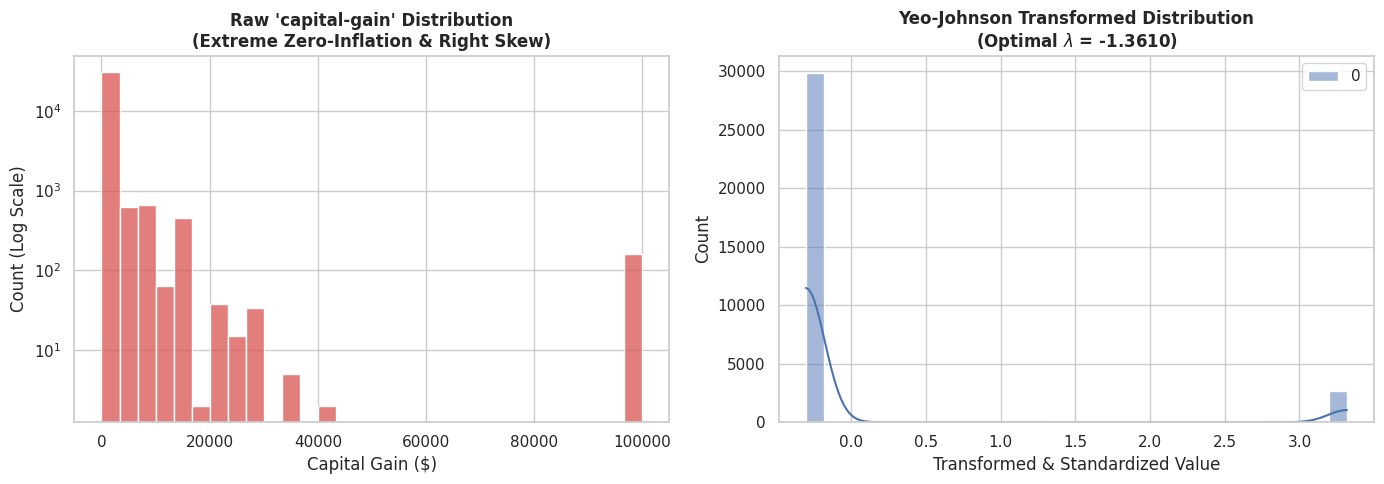

Raw Skewness       : 11.9538
Transformed Skewness: 3.0163
Optimal Lambda (λ) : -1.3610


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# 1. Fit Yeo-Johnson PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
capital_gain_trans = pt.fit_transform(df_clean[['capital-gain']])

# 2. Plot Raw vs. Transformed Distributions
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Distribution (Log-scale Y-axis to highlight extreme skew)
sns.histplot(df_clean['capital-gain'], kde=False, ax=axes[0], color='#D9534F', bins=30)
axes[0].set_title("Raw 'capital-gain' Distribution\n(Extreme Zero-Inflation & Right Skew)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Capital Gain ($)")
axes[0].set_ylabel("Count (Log Scale)")
axes[0].set_yscale('log')

# Yeo-Johnson Transformed Distribution
sns.histplot(capital_gain_trans, kde=True, ax=axes[1], color='#0275D8', bins=30)
axes[1].set_title(f"Yeo-Johnson Transformed Distribution\n(Optimal $\lambda$ = {pt.lambdas_[0]:.4f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Transformed & Standardized Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# 3. Print Skewness Reduction Metrics
print(f"Raw Skewness       : {df_clean['capital-gain'].skew():.4f}")
print(f"Transformed Skewness: {pd.Series(capital_gain_trans.flatten()).skew():.4f}")
print(f"Optimal Lambda (λ) : {pt.lambdas_[0]:.4f}")